<a href="https://colab.research.google.com/github/LegalmenteCarlo/Carlos-Jurado-Marcos---Final---deep-learning/blob/main/notebooks/TAF_Grupo_2_Estructura_Final_Project_2_Tecnicas_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|---|---|
| **Integrantes** | Adriana Kiyan Oshiro · Cristhian Vasquez Jimenez · Carlos Jurado Marcos · Martín Loconi Yahuana |
| **Título del Proyecto** | Motor de Automatización de Clasificación de Sentimiento: Caso Rotten Tomatoes |
| **Tipo de Proyecto** | Deep Learning + Procesamiento de Lenguaje Natural (NLP) |
| **Caso de estudio** | Clasificación automática de reviews cinematográficas como Fresh o Rotten |

---


## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)
12. [Anexos](#anexos)


---
## 1. Resumen Ejecutivo

El proyecto desarrolla un motor de clasificación automática de sentimiento aplicado a críticas cinematográficas. El problema parte de la dificultad de analizar manualmente grandes volúmenes de opiniones no estructuradas, por lo que se propone un pipeline escalable basado en Procesamiento de Lenguaje Natural (NLP) y Deep Learning.

El dataset contiene aproximadamente 1.44 millones de registros originales. Después de eliminar registros sin texto o sin clasificación válida, se trabaja con aproximadamente 1.37 millones de reviews. La variable objetivo distingue entre **Fresh (1)** y **Rotten (0)**, con una distribución aproximada de 67% y 33%, respectivamente.

El procesamiento utiliza `TextVectorization` para transformar las reseñas en secuencias numéricas y una capa `Embedding` para representar los tokens. Para cumplir con la comparación de **mínimo dos técnicas de Deep Learning**, se entrenan dos arquitecturas sobre exactamente las mismas particiones de datos: una **Bidirectional LSTM (BiLSTM)**, orientada a capturar dependencias secuenciales y contexto, y una **CNN 1D**, orientada a detectar patrones locales relevantes en el texto.

Ambos modelos se evalúan sobre el mismo conjunto Test mediante Accuracy, Precision, Recall, AUC y F1-score. La comparación permite seleccionar de manera cuantitativa la arquitectura que generaliza mejor antes de utilizarla para inferencia y guardado final.


---
## 2. Configuración del Entorno

### 2.1 Verificación de GPU


In [ ]:
# Verificar disponibilidad de GPU
import tensorflow as tf

print("Versión TensorFlow:", tf.__version__)
print("GPU disponibles:", tf.config.list_physical_devices("GPU"))


Versión TensorFlow: 2.20.0
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2.2 Instalación de Librerías Adicionales

En el desarrollo actual no se requieren instalaciones adicionales si el entorno ya cuenta con TensorFlow, pandas, NumPy, Matplotlib y scikit-learn.


### 2.3 Importación de Librerías


In [ ]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 200)


### 2.4 Conexión con Google Drive / Fuente de Datos

El notebook original carga el archivo directamente desde `/content/`. Si el dataset se encuentra en Google Drive, se puede montar Drive antes de definir la ruta.


In [ ]:
# Opcional en Google Colab:
# from google.colab import drive
# drive.mount('/content/drive')


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

Las empresas de la industria cinematográfica y las plataformas de streaming reciben grandes cantidades de críticas y opiniones sobre sus contenidos. Estas opiniones contienen información sobre la percepción del público y de los críticos, pero se presentan principalmente como texto no estructurado.

Analizar manualmente este volumen de información es costoso, lento y poco escalable.


### 3.2 Problema a Resolver

Se busca automatizar la lectura de críticas cinematográficas para determinar si el sentimiento expresado corresponde a una clasificación **Fresh** o **Rotten**.

La automatización permite transformar texto libre en una señal cuantificable de sentimiento que puede utilizarse para monitorear la percepción de contenidos y apoyar decisiones de marketing y gestión de contenido.


### 3.3 Objetivos del Proyecto

**Objetivo General**

Desarrollar y comparar un pipeline escalable de Deep Learning basado en NLP que clasifique automáticamente reviews cinematográficas como Fresh o Rotten a partir del texto escrito por los críticos.

**Objetivos Específicos**

1. Explorar y limpiar el dataset, identificando registros incompletos y la distribución de las clases.
2. Preparar el texto mediante tokenización y vectorización para su procesamiento por redes neuronales.
3. Diseñar y entrenar dos arquitecturas de Deep Learning: **Bidirectional LSTM** y **CNN 1D**.
4. Comparar ambas técnicas utilizando las mismas particiones y métricas de clasificación.
5. Analizar errores y seleccionar el modelo con mejor generalización para construir una función de inferencia sobre nuevas reseñas.


### 3.4 Tipo de Problema de Machine Learning

- [x] Clasificación binaria
- [ ] Clasificación multiclase
- [ ] Regresión
- [ ] Clustering
- [ ] Series temporales
- [x] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora

**Justificación:** la entrada principal es texto y la variable objetivo tiene dos categorías: **Fresh** y **Rotten**. Por ello, el problema corresponde a una clasificación binaria aplicada a NLP.


---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos


In [ ]:
# ============================================================
# 2. CARGAR EL DATASET
# ============================================================

# Ruta donde se encuentra el archivo CSV
file_path = "/content/rotten_tomatoes_movie_reviews.csv.zip"

df = pd.read_csv(file_path)

# Mostrar dimensiones del dataset
print("Filas y columnas:", df.shape)

# Mostrar las primeras filas
df.head()

Filas y columnas: (1444963, 11)


,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),"Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.",POSITIVE,http://www.deseretnews.com/article/700003233/Beavers.html
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,"It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.",NEGATIVE,http://www.dreadcentral.com/index.php?name=Reviews&req=showcontent&id=1466
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,"The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of the anima...",POSITIVE,https://www.cbr.com/city-hunter-shinjuku-private-eyes-review/
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may find them hunting for the reason the franchise was so popular in the first place.,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/06/films/film-reviews/city-hunter-movie-shinjuku-private-eyes-dated-gags-modern-day-tokyo/#.XGXYvJNKjOS
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and sometimes wildly entertaining,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerous_men.php


### 4.2 Descripción del Dataset

El dataset contiene críticas cinematográficas y variables relacionadas con la reseña y el crítico. Para el proyecto se seleccionan las siguientes variables:

| Variable | Tipo | Descripción |
|---|---|---|
| `reviewText` | Texto | Contenido escrito de la crítica. |
| `reviewState` | Categórica | Clasificación original: Fresh o Rotten. |
| `creationDate` | Fecha | Fecha de creación/publicación de la review. |
| `isTopCritic` | Categórica/booleana | Identifica si la reseña pertenece a un Top Critic. |
| `publicatioName` | Categórica | Medio o publicación asociada a la crítica. |
| `label` | Binaria | Variable objetivo creada: Fresh = 1, Rotten = 0. |


### 4.3 Exploración Inicial de Datos (EDA)


In [ ]:
# ============================================================
# 3. EXPLORACIÓN INICIAL
# ============================================================

# Mostrar nombres de todas las columnas
print(df.columns.tolist())

['id', 'reviewId', 'creationDate', 'criticName', 'isTopCritic', 'originalScore', 'reviewState', 'publicatioName', 'reviewText', 'scoreSentiment', 'reviewUrl']


In [ ]:
# Revisar información general:
# tipo de dato, cantidad de registros, valores no nulos, etc.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1444963 entries, 0 to 1444962
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   id              1444963 non-null  object
 1   reviewId        1444963 non-null  int64 
 2   creationDate    1444963 non-null  object
 3   criticName      1444963 non-null  object
 4   isTopCritic     1444963 non-null  bool  
 5   originalScore   1009745 non-null  object
 6   reviewState     1444963 non-null  object
 7   publicatioName  1444963 non-null  object
 8   reviewText      1375738 non-null  object
 9   scoreSentiment  1444963 non-null  object
 10  reviewUrl       1234038 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 111.6+ MB


In [ ]:
# ============================================================
# 4. SELECCIONAR VARIABLES IMPORTANTES
# ============================================================

columnas = [
    "reviewText",
    "reviewState",
    "creationDate",
    "isTopCritic",
    "publicatioName"
]

df = df[columnas].copy()

df.head()

,reviewText,reviewState,creationDate,isTopCritic,publicatioName
0,"Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.",fresh,2003-05-23,False,Deseret News (Salt Lake City)
1,"It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.",rotten,2007-06-02,False,Dread Central
2,"The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of the anima...",fresh,2019-05-28,False,CBR
3,The film's out-of-touch attempts at humor may find them hunting for the reason the franchise was so popular in the first place.,rotten,2019-02-14,False,Japan Times
4,Its clumsy determination is endearing and sometimes wildly entertaining,fresh,2018-08-29,False,DCist


In [ ]:
# ============================================================
# 5. ANALIZAR DATOS FALTANTES
# ============================================================

# Contar valores nulos por columna
nulos = df.isnull().sum()

print(nulos)

reviewText        69225
reviewState           0
creationDate          0
isTopCritic           0
publicatioName        0
dtype: int64


In [ ]:
# Calcular porcentaje de valores nulos

porcentaje_nulos = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

porcentaje_nulos

,0
reviewText,4.79078
reviewState,0.00000
creationDate,0.00000
isTopCritic,0.00000
publicatioName,0.00000


#### Análisis de valores nulos

Se revisa la presencia de valores faltantes. Para el entrenamiento son indispensables `reviewText` y `reviewState`; por ello, los registros sin información en estas variables no pueden aportar patrones de texto útiles al modelo.


In [ ]:
# ============================================================
# 6. LIMPIEZA DE DATOS
# ============================================================

# Eliminar filas donde reviewText o reviewState tengan valores nulos
df = df.dropna(
    subset=[
        "reviewText",
        "reviewState"
    ]
)

print("Registros después de eliminar nulos:", len(df))

Registros después de eliminar nulos: 1375738


In [ ]:
# Ver qué valores existen en reviewState

df["reviewState"].value_counts()

,count
reviewState,
fresh,922510
rotten,453228


In [ ]:
# Convertimos todos los valores a minúsculas
# y eliminamos espacios innecesarios.

df["reviewState"] = (
    df["reviewState"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["reviewState"].value_counts()

,count
reviewState,
fresh,922510
rotten,453228


In [ ]:
# ============================================================
# 8. FILTRAR CLASES
# ============================================================

df = df[
    df["reviewState"].isin(
        ["fresh", "rotten"]
    )
].copy()

print(df["reviewState"].value_counts())

reviewState
fresh     922510
rotten    453228
Name: count, dtype: int64


In [ ]:
# ============================================================
# 9. CREAR VARIABLE OBJETIVO
# ============================================================

df["label"] = df["reviewState"].map(
    {
        "fresh": 1,
        "rotten": 0
    }
)

# Revisar resultado
df[
    [
        "reviewText",
        "reviewState",
        "label"
    ]
].head()

,reviewText,reviewState,label
0,"Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.",fresh,1
1,"It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.",rotten,0
2,"The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of the anima...",fresh,1
3,The film's out-of-touch attempts at humor may find them hunting for the reason the franchise was so popular in the first place.,rotten,0
4,Its clumsy determination is endearing and sometimes wildly entertaining,fresh,1


In [ ]:
# ============================================================
# 10. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

conteo = df["reviewState"].value_counts()

print(conteo)
porcentaje = (
    df["reviewState"]
    .value_counts(normalize=True)
    * 100
)

print(porcentaje)

reviewState
fresh     922510
rotten    453228
Name: count, dtype: int64
reviewState
fresh     67.055646
rotten    32.944354
Name: proportion, dtype: float64


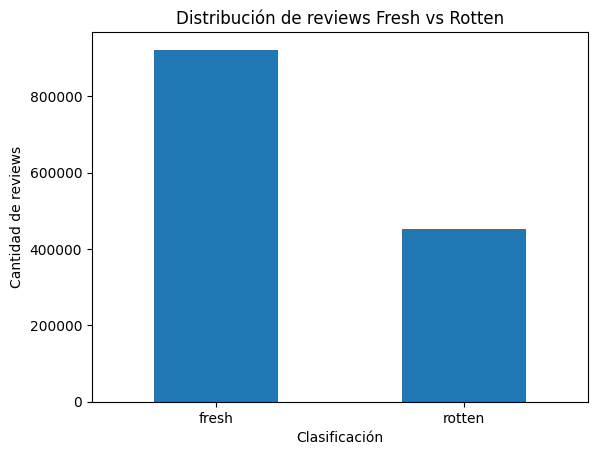

In [ ]:
# Gráfico de distribución

df["reviewState"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución de reviews Fresh vs Rotten")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de reviews")
plt.xticks(rotation=0)
plt.show()

#### Distribución de clases

Se analiza la proporción de críticas Fresh y Rotten para identificar posibles efectos de desbalance de clases. En el dataset limpio existe una mayor proporción de Fresh que de Rotten.


In [ ]:
# ============================================================
# 11. LONGITUD DE LAS REVIEWS
# ============================================================

# Crear una variable con cantidad de caracteres
df["review_length"] = (
    df["reviewText"]
    .astype(str)
    .str.len()
)

df["review_length"].describe()

,review_length
count,1.375738e+06
mean,1.315793e+02
std,5.679759e+01
min,1.000000e+00
25%,8.900000e+01
50%,1.300000e+02
75%,1.710000e+02
max,3.630000e+02


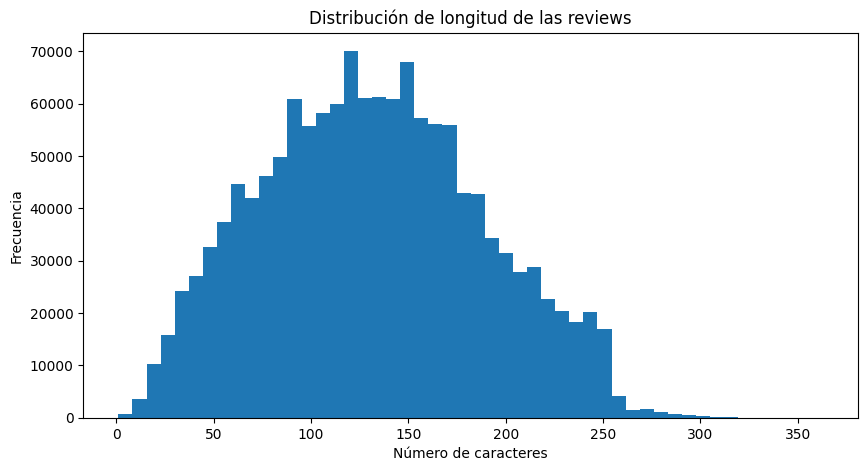

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Distribución de longitud de las reviews")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")

plt.show()

In [ ]:
# Revisar distribución Top Critic

df["isTopCritic"].value_counts(dropna=False)

,count
isTopCritic,
False,949438
True,426300


In [ ]:
pd.crosstab(
    df["isTopCritic"],
    df["reviewState"],
    normalize="index"
) * 100

reviewState,fresh,rotten
isTopCritic,,
False,68.753515,31.246485
True,63.274220,36.725780


#### Análisis de longitud y críticos

La longitud de las reviews permite entender el tamaño típico de los textos que procesará el modelo. También se revisa si los Top Critics presentan una distribución de clasificación diferente al resto.


In [ ]:
# ============================================================
# 13. PUBLICACIONES CON MAYOR CANTIDAD DE REVIEWS
# ============================================================

df["publicatioName"].value_counts().head(10)

,count
publicatioName,
New York Times,19646
Variety,17572
Los Angeles Times,14347
Hollywood Reporter,13710
Dennis Schwartz Movie Reviews,13124
Slant Magazine,11763
Guardian,11159
Common Sense Media,10882
Village Voice,10684


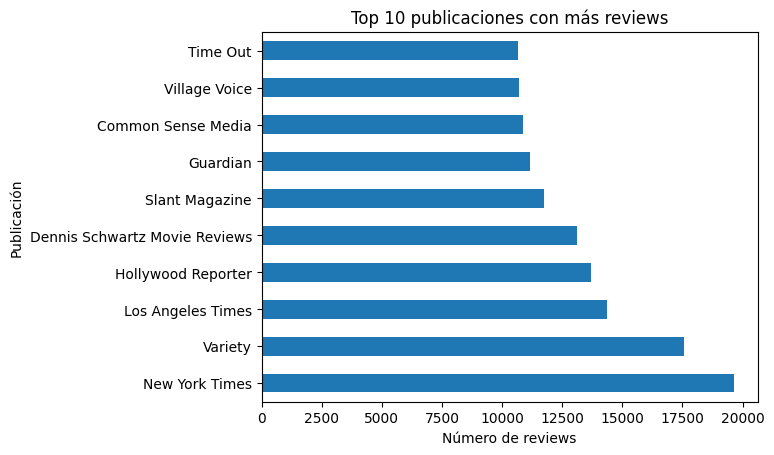

In [ ]:
df["publicatioName"].value_counts().head(10).plot(
    kind="barh"
)

plt.title("Top 10 publicaciones con más reviews")
plt.xlabel("Número de reviews")
plt.ylabel("Publicación")

plt.show()

### 4.4 Hallazgos del EDA

**Hallazgos Principales**

1. El dataset original contiene alrededor de 1.44 millones de registros.
2. Existen registros sin texto que deben eliminarse porque el modelo aprende directamente del contenido de la review.
3. Después de la limpieza se trabaja con aproximadamente 1.37 millones de reseñas válidas.
4. La distribución es aproximadamente 67% Fresh y 33% Rotten, por lo que existe desbalance de clases.
5. Las reseñas son relativamente cortas; la longitud media observada es cercana a 132 caracteres.

**Problemas Identificados**

1. Valores faltantes en variables necesarias para el entrenamiento.
2. Desbalance entre las clases Fresh y Rotten.
3. Datos textuales que requieren transformación a una representación numérica.

**Acciones a Tomar**

1. Eliminar registros sin `reviewText` o `reviewState`.
2. Codificar la variable objetivo como 0/1.
3. Dividir cronológicamente los datos en Train, Validation y Test.
4. Vectorizar el texto antes de ingresarlo a la red neuronal.


---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

Los registros sin `reviewText` o `reviewState` se eliminan porque no contienen la información mínima necesaria para relacionar un texto con una etiqueta de sentimiento.


### 5.2 Tratamiento de Outliers

Al tratarse principalmente de texto, no se realiza un tratamiento tradicional de outliers numéricos. En cambio, se analiza la longitud de las reviews y posteriormente se limita la entrada del modelo a una secuencia máxima de **200 tokens** mediante `TextVectorization`.


### 5.3 Codificación de Variables Categóricas

La variable objetivo se convierte a formato binario:

- `Fresh` = 1
- `Rotten` = 0

Esta codificación permite utilizar `binary_crossentropy` como función de pérdida y Sigmoid como función de salida.


### 5.4 Escalado/Normalización de Features

No se aplica escalado numérico tradicional, ya que la entrada principal es texto. La transformación se realiza mediante `TextVectorization` y `Embedding`.


### 5.5 División de Datos (Train/Validation/Test)

La división se realiza cronológicamente: 80% para entrenamiento, 10% para validación y 10% para prueba. Esto busca simular un escenario en el que el modelo aprende de reseñas históricas y posteriormente clasifica reseñas más recientes.


In [ ]:
# ============================================================
# 14. CONVERTIR creationDate A FECHA
# ============================================================

df["creationDate"] = pd.to_datetime(
    df["creationDate"],
    errors="coerce"
)

# Eliminar registros donde no se pudo identificar la fecha
df = df.dropna(
    subset=["creationDate"]
)

df["creationDate"].describe()

,creationDate
count,1375738
mean,2013-09-05 09:32:26.898028032
min,1800-01-01 00:00:00
25%,2008-01-22 00:00:00
50%,2014-12-11 00:00:00
75%,2019-07-15 00:00:00
max,2023-04-08 00:00:00


In [ ]:
# Ordenar desde las reviews más antiguas
# hasta las más recientes

df = (
    df
    .sort_values("creationDate")
    .reset_index(drop=True)
)

df.head()

,reviewText,reviewState,creationDate,isTopCritic,publicatioName,label,review_length
0,The choreographed routines and editing have such dizzy energy they carry it aloft.,fresh,1800-01-01,True,Daily Telegraph (UK),1,82
1,"All in all, AIrborne is not bad for what it is, but what it is is very little.",rotten,1800-01-01,True,Austin Chronicle,0,78
2,"'Every Day,' while enjoyable, feels very much like the work of a writer/director best known for slick, well-made television.",fresh,1800-01-01,True,DVDTalk.com,1,124
3,"A bright, cheery pop confection, the entertaining tale of ""how one man changed the world with a pair of scissors.""",fresh,1800-01-01,True,DVDTalk.com,1,114
4,"It's as effective in 2009 as it was upon its initial release, and the richness of its tapestry, densely woven from human emotions and character interaction, ensure it will never lose that relevance.",fresh,1800-01-01,True,ReelViews,1,198


In [ ]:
# ============================================================
# 16. DIVISIÓN DEL DATASET
# ============================================================

n = len(df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1100590, 7)
Validation: (137574, 7)
Test: (137574, 7)


In [ ]:
print(
    "Train:",
    train_df["creationDate"].min(),
    "-",
    train_df["creationDate"].max()
)

print(
    "Validation:",
    val_df["creationDate"].min(),
    "-",
    val_df["creationDate"].max()
)

print(
    "Test:",
    test_df["creationDate"].min(),
    "-",
    test_df["creationDate"].max()
)

Train: 1800-01-01 00:00:00 - 2020-03-19 00:00:00
Validation: 2020-03-19 00:00:00 - 2021-09-03 00:00:00
Test: 2021-09-03 00:00:00 - 2023-04-08 00:00:00


### 5.6 Preparación de Datos para Deep Learning

Los subconjuntos se convierten a objetos `tf.data.Dataset`. Se utiliza un `BATCH_SIZE` de 256, `shuffle` únicamente en entrenamiento y `prefetch(tf.data.AUTOTUNE)` para mejorar la eficiencia del pipeline.


In [ ]:
# ============================================================
# 17. CREAR PIPELINE TF.DATA
# ============================================================

# Número de registros procesados simultáneamente
BATCH_SIZE = 256

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["reviewText"].astype(str).values,
        train_df["label"].values
    )
)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["reviewText"].astype(str).values,
        val_df["label"].values
    )
)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["reviewText"].astype(str).values,
        test_df["label"].values
    )
)

In [ ]:
# ============================================================
# 18. OPTIMIZAR EL PIPELINE
# ============================================================

# Shuffle mezcla los datos de entrenamiento
# para evitar que la red aprenda según el orden.

train_ds = (
    train_ds
    .shuffle(50000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation y Test no necesitan shuffle

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

#### Pipeline de procesamiento de texto (NLP)

`TextVectorization` construye un vocabulario usando únicamente los datos de entrenamiento. Cada review se transforma en una secuencia de hasta 200 tokens, con un vocabulario máximo de 30,000 términos.


In [ ]:
# ============================================================
# 19. TOKENIZACIÓN DEL TEXTO
# ============================================================

# Número máximo de palabras diferentes
MAX_TOKENS = 30000

# Número máximo de tokens por review
SEQUENCE_LENGTH = 200

In [ ]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

In [ ]:
# Extraemos únicamente el texto del dataset de entrenamiento

train_text = train_ds.map(
    lambda text, label: text
)

In [ ]:
# ============================================================
# 21. APRENDER VOCABULARIO
# ============================================================

vectorizer.adapt(train_text)

print("Vocabulario creado correctamente.")

Vocabulario creado correctamente.


In [ ]:
vocabulary = vectorizer.get_vocabulary()

print("Tamaño del vocabulario:", len(vocabulary))

print(
    "Primeras palabras:",
    vocabulary[:30]
)

Tamaño del vocabulario: 30000
Primeras palabras: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('and'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('its'), np.str_('that'), np.str_('it'), np.str_('as'), np.str_('but'), np.str_('with'), np.str_('this'), np.str_('for'), np.str_('film'), np.str_('an'), np.str_('on'), np.str_('movie'), np.str_('be'), np.str_('you'), np.str_('not'), np.str_('by'), np.str_('at'), np.str_('one'), np.str_('are'), np.str_('from'), np.str_('more')]


In [ ]:
# ============================================================
# 23. EJEMPLO DE TOKENIZACIÓN
# ============================================================

ejemplo = tf.constant([
    "This movie was absolutely fantastic and the performances were excellent"
])

vectorizado = vectorizer(ejemplo)

print(vectorizado)

tf.Tensor(
[[ 15  20  70 744 895   4   2 113 174 525   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]], shape=(1, 200), dtype=int64)


---
## 6. Diseño y Arquitectura de los Modelos

### 6.1 Justificación de las Arquitecturas

Se comparan dos técnicas de Deep Learning para clasificación de texto usando **el mismo preprocesamiento, vocabulario y particiones Train/Validation/Test**, de modo que la comparación sea justa.

**Modelo 1 — Bidirectional LSTM (BiLSTM).** `TextVectorization` transforma el texto en tokens y `Embedding` aprende una representación vectorial. La BiLSTM procesa la secuencia en ambas direcciones para capturar dependencias y contexto entre palabras, algo relevante cuando el significado depende del orden de la frase.

**Modelo 2 — CNN 1D.** Después de `TextVectorization` y `Embedding`, una capa `Conv1D` aplica filtros sobre ventanas consecutivas de tokens. Esto permite aprender patrones locales o expresiones cortas que pueden ser muy informativas para sentimiento, por ejemplo combinaciones equivalentes a “waste of time” o “highly entertaining”. `GlobalMaxPooling1D` conserva las activaciones más relevantes detectadas por los filtros.

Las dos arquitecturas incorporan `Dropout` como regularización y terminan en una neurona con activación Sigmoid para estimar la probabilidad de la clase Fresh.


### 6.2 Modelo 1: Bidirectional LSTM


In [ ]:
# ============================================================
# CREAR Y COMPILAR EL MODELO
# Ejecutar antes de la Parte 29
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Crear el modelo
model = keras.Sequential([

    # Entrada: texto de la review
    layers.Input(
        shape=(),
        dtype=tf.string
    ),

    # Convierte el texto en números
    vectorizer,

    # Convierte cada palabra en un vector
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=128,
        mask_zero=True
    ),

    # Red neuronal LSTM bidireccional
    layers.Bidirectional(
        layers.LSTM(64, use_cudnn=False) # Corregido: Añadir use_cudnn=False
    ),

    # Regularización para evitar overfitting
    layers.Dropout(0.4),

    # Capa oculta
    layers.Dense(
        64,
        activation="relu"
    ),

    # Segunda regularización
    layers.Dropout(0.3),

    # Salida:
    # 0 = Rotten
    # 1 = Fresh
    layers.Dense(
        1,
        activation="sigmoid"
    )
])


# ============================================================
# COMPILAR EL MODELO
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print("Modelo creado y compilado correctamente.")

model.summary()

Modelo creado y compilado correctamente.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Arquitectura BiLSTM

```text
Review de texto
      ↓
TextVectorization
(vocabulario máx. 30,000; secuencia 200 tokens)
      ↓
Embedding (128 dimensiones)
      ↓
Bidirectional LSTM (64 unidades por dirección)
      ↓
Dropout (0.4)
      ↓
Dense (64, ReLU)
      ↓
Dropout (0.3)
      ↓
Dense (1, Sigmoid)
      ↓
Probabilidad Fresh / Rotten
```



#### Regularización y callbacks


In [ ]:
# ============================================================
# 27. EARLY STOPPING
# ============================================================

# Detendrá el entrenamiento si val_loss
# deja de mejorar durante 2 épocas.

early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=2,

    # Recuperar los mejores pesos encontrados
    restore_best_weights=True
)

In [ ]:
# Guardará el modelo con menor validation loss

checkpoint = keras.callbacks.ModelCheckpoint(

    "best_bilstm_model.keras",

    monitor="val_loss",

    save_best_only=True
)


---
## 7. Entrenamiento de los Modelos

### 7.1 Configuración del Entrenamiento

Ambos modelos utilizan Adam, `binary_crossentropy` y monitorean Accuracy, Precision, Recall y AUC. Para mantener una comparación consistente, los dos usan el mismo número máximo de épocas, `steps_per_epoch` y `validation_steps`. Cada arquitectura posee sus propios callbacks `EarlyStopping` y `ModelCheckpoint`.


### 7.2 Entrenamiento del Modelo (PyTorch)

**No aplica en esta implementación.** El proyecto se desarrolló con TensorFlow/Keras.


### 7.3 Entrenamiento del Modelo 1 — BiLSTM (Keras)

La BiLSTM se ejecuta durante un máximo de 3 épocas. Para reducir el tiempo de procesamiento en Colab se usan 300 batches por época y 50 pasos de validación. La CNN utilizará la misma configuración para mantener comparabilidad.


In [ ]:
# ============================================================
# 29. ENTRENAMIENTO
# ============================================================

history = model.fit(

    train_ds,

    validation_data=val_ds,

    # Para la prueba usamos pocas épocas
    epochs=3,

    # Solo procesamos 300 batches por época
    # en lugar de los 4300 completos
    steps_per_epoch=300,

    # También reducimos la validación
    validation_steps=50,

    callbacks=[
        early_stopping,
        checkpoint
    ],

    verbose=1
)

Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.7597 - auc: 0.8416 - loss: 0.4792 - precision: 0.7693 - recall: 0.8503 - val_accuracy: 0.8205 - val_auc: 0.8730 - val_loss: 0.3865 - val_precision: 0.8824 - val_recall: 0.8749
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 296s 986ms/step - accuracy: 0.8097 - auc: 0.8881 - loss: 0.4090 - precision: 0.8372 - recall: 0.8534 - val_accuracy: 0.7880 - val_auc: 0.8853 - val_loss: 0.4332 - val_precision: 0.9284 - val_recall: 0.7743
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 298s 991ms/step - accuracy: 0.8147 - auc: 0.8924 - loss: 0.4028 - precision: 0.8437 - recall: 0.8504 - val_accuracy: 0.8437 - val_auc: 0.9084 - val_loss: 0.3426 - val_precision: 0.9163 - val_recall: 0.8689


In [ ]:
# ============================================================
# 30. HISTORIAL DEL ENTRENAMIENTO
# ============================================================

history_df = pd.DataFrame(
    history.history
)

history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.759687,0.841559,0.479233,0.769257,0.850272,0.820469,0.873027,0.386532,0.882359,0.874934
1,0.809714,0.888092,0.408965,0.837194,0.853415,0.787969,0.885338,0.433233,0.928364,0.774272
2,0.814674,0.892437,0.402768,0.843728,0.850373,0.843672,0.908373,0.342650,0.916260,0.868939


### 7.4 Visualización del Entrenamiento

Se comparan las curvas de Loss y Accuracy de entrenamiento y validación. Una separación creciente entre ambas curvas puede indicar overfitting.


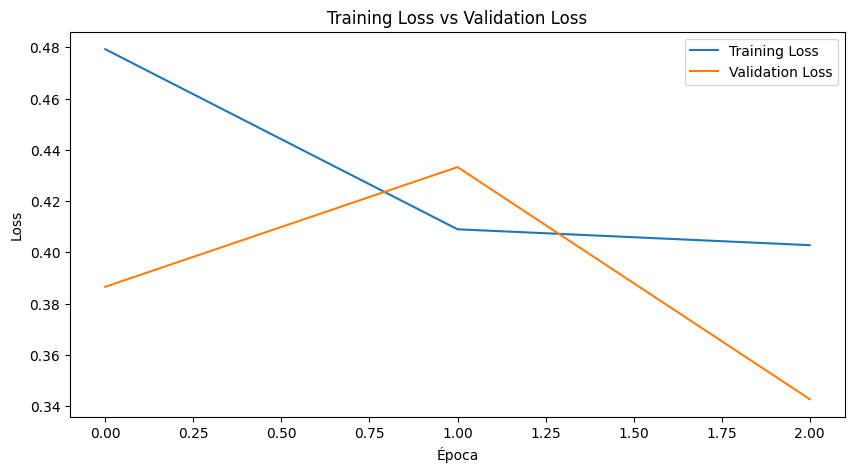

In [ ]:
# ============================================================
# Gráfico Loss
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training Loss vs Validation Loss")

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()

plt.show()

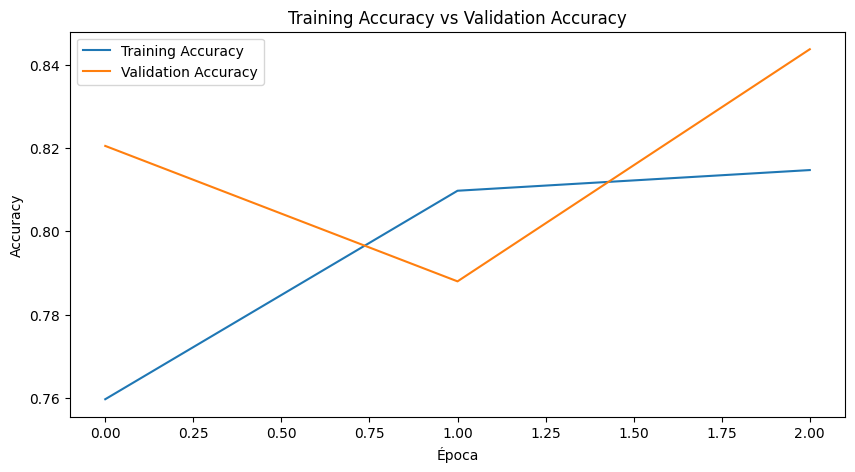

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training Accuracy vs Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

---
## 8. Evaluación y Comparación de Técnicas

### 8.1 Evaluación del Modelo 1 — BiLSTM

El conjunto Test contiene reseñas no utilizadas durante el entrenamiento. Primero se evalúa la BiLSTM mediante Accuracy, Precision, Recall, AUC y posteriormente F1-score.


In [ ]:
# ============================================================
# 33. EVALUACIÓN FINAL
# ============================================================

results = model.evaluate(
    test_ds,
    return_dict=True
)

results

538/538 ━━━━━━━━━━━━━━━━━━━━ 122s 227ms/step - accuracy: 0.8362 - auc: 0.8994 - loss: 0.3550 - precision: 0.9124 - recall: 0.8646


{'accuracy': 0.8361972570419312,
 'auc': 0.8994245529174805,
 'loss': 0.3549688160419464,
 'precision': 0.9123532176017761,
 'recall': 0.8646017909049988}

In [ ]:
print(
    "Accuracy:",
    round(results["accuracy"], 4)
)

print(
    "Precision:",
    round(results["precision"], 4)
)

print(
    "Recall:",
    round(results["recall"], 4)
)

print(
    "AUC:",
    round(results["auc"], 4)
)

Accuracy: 0.8362
Precision: 0.9124
Recall: 0.8646
AUC: 0.8994


In [ ]:
# ============================================================
# 34. PREDICCIONES SOBRE TEST
# ============================================================

# El modelo devuelve probabilidades
pred_prob = model.predict(
    test_ds
).ravel()

pred_prob[:10]

538/538 ━━━━━━━━━━━━━━━━━━━━ 118s 218ms/step


array([0.08389397, 0.9671555 , 0.7810543 , 0.00949057, 0.9036564 ,
       0.18071887, 0.99405366, 0.41496676, 0.9969302 , 0.57370555],
      dtype=float32)

In [ ]:
y_pred = (
    pred_prob >= 0.5
).astype(int)

y_pred[:20]

array([0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0])

In [ ]:
y_true = test_df["label"].values

In [ ]:
# ============================================================
# 37. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(

        y_true,

        y_pred,

        target_names=[
            "Rotten",
            "Fresh"
        ]
    )
)

              precision    recall  f1-score   support

      Rotten       0.65      0.75      0.70     34419
       Fresh       0.91      0.86      0.89    103155

    accuracy                           0.84    137574
   macro avg       0.78      0.81      0.79    137574
weighted avg       0.85      0.84      0.84    137574



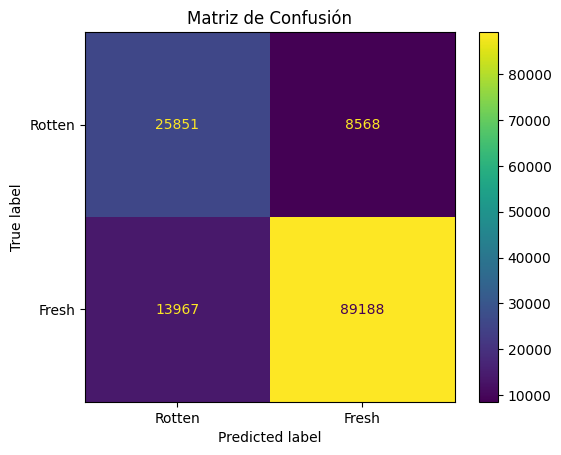

In [ ]:
# ============================================================
# 38. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Rotten",
        "Fresh"
    ]
)

disp.plot()

plt.title(
    "Matriz de Confusión"
)

plt.show()

#### Matriz de Confusión — BiLSTM

La diagonal representa predicciones correctas y los valores fuera de la diagonal representan errores de clasificación. Esta matriz se comparará con la correspondiente a la CNN 1D.


### 8.2 Modelo 2 — CNN 1D

La segunda técnica utiliza convoluciones unidimensionales sobre las representaciones `Embedding`. A diferencia de la BiLSTM, que busca dependencias secuenciales, la CNN detecta **patrones locales** de tokens y puede procesarlos de forma altamente paralelizable. Se mantiene el mismo conjunto de datos y configuración general de entrenamiento para que las métricas sean comparables.


In [ ]:
# ============================================================
# 39. CREAR Y COMPILAR MODELO 2: CNN 1D
# ============================================================

cnn_model = keras.Sequential([
    layers.Input(shape=(), dtype=tf.string),
    vectorizer,

    # En CNN no usamos mask_zero porque Conv1D no propaga máscaras.
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=128
    ),

    # Detecta patrones locales de hasta 5 tokens consecutivos.
    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    # Conserva la activación más relevante de cada filtro.
    layers.GlobalMaxPooling1D(),

    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930,369 (14.99 MB)

 Trainable params: 3,930,369 (14.99 MB)

 Non-trainable params: 0 (0.00 B)

#### Arquitectura CNN 1D

```text
Review de texto
      ↓
TextVectorization
      ↓
Embedding (128 dimensiones)
      ↓
Conv1D (128 filtros, kernel = 5, ReLU)
      ↓
GlobalMaxPooling1D
      ↓
Dropout (0.4)
      ↓
Dense (64, ReLU)
      ↓
Dropout (0.3)
      ↓
Dense (1, Sigmoid)
      ↓
Probabilidad Fresh / Rotten
```

El `kernel_size=5` permite que cada filtro observe ventanas locales de hasta cinco tokens. `GlobalMaxPooling1D` resume cada filtro tomando la señal más fuerte encontrada en toda la reseña.


In [ ]:
# ============================================================
# 40. CALLBACKS EXCLUSIVOS PARA CNN
# ============================================================

cnn_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

cnn_checkpoint = keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True
)


In [ ]:
# ============================================================
# 41. ENTRENAMIENTO CNN 1D
# Mismos límites que la BiLSTM para una comparación justa
# ============================================================

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    steps_per_epoch=300,
    validation_steps=50,
    callbacks=[cnn_early_stopping, cnn_checkpoint],
    verbose=1
)


Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7292 - auc: 0.8054 - loss: 0.5202 - precision: 0.7291 - recall: 0.8663 - val_accuracy: 0.8196 - val_auc: 0.8789 - val_loss: 0.3944 - val_precision: 0.8976 - val_recall: 0.8546
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8013 - auc: 0.8777 - loss: 0.4263 - precision: 0.8309 - recall: 0.8459 - val_accuracy: 0.8356 - val_auc: 0.8953 - val_loss: 0.3625 - val_precision: 0.9040 - val_recall: 0.8713
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8038 - auc: 0.8821 - loss: 0.4212 - precision: 0.8314 - recall: 0.8452 - val_accuracy: 0.8426 - val_auc: 0.9015 - val_loss: 0.3546 - val_precision: 0.9025 - val_recall: 0.8835


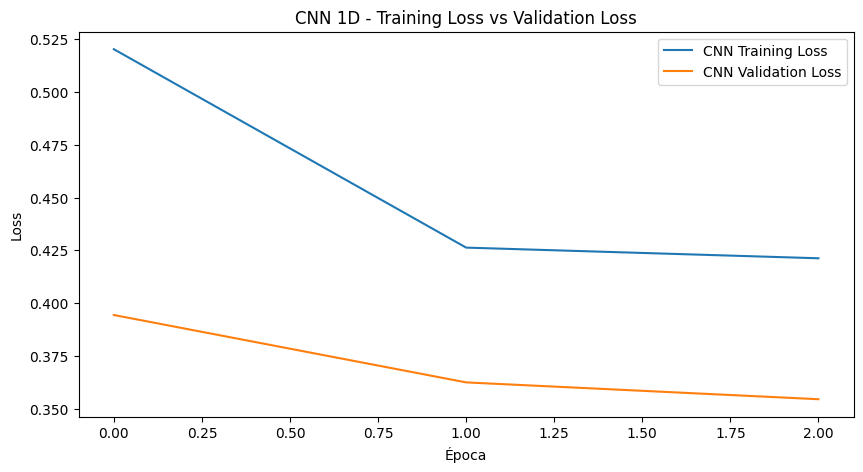

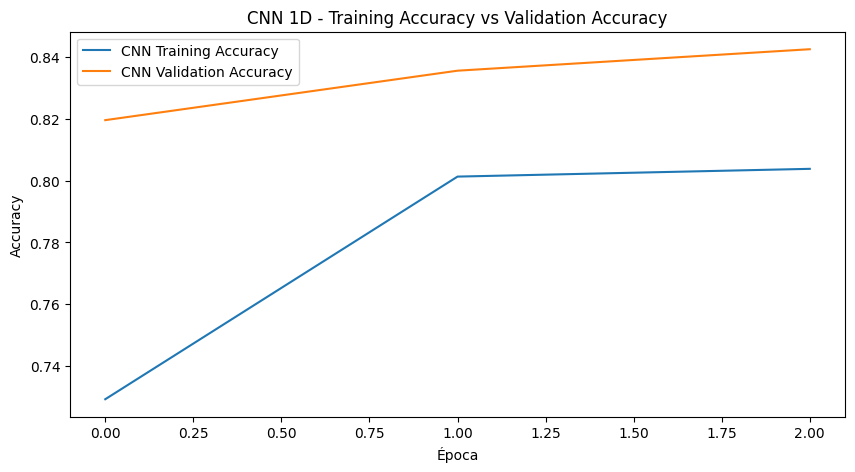

In [ ]:
# ============================================================
# 42. CURVAS DE ENTRENAMIENTO CNN
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(cnn_history.history["loss"], label="CNN Training Loss")
plt.plot(cnn_history.history["val_loss"], label="CNN Validation Loss")
plt.title("CNN 1D - Training Loss vs Validation Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(cnn_history.history["accuracy"], label="CNN Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="CNN Validation Accuracy")
plt.title("CNN 1D - Training Accuracy vs Validation Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
# ============================================================
# 43. EVALUACIÓN CNN SOBRE EL MISMO TEST
# ============================================================

cnn_results = cnn_model.evaluate(
    test_ds,
    return_dict=True
)

print("CNN Accuracy:", round(cnn_results["accuracy"], 4))
print("CNN Precision:", round(cnn_results["precision"], 4))
print("CNN Recall:", round(cnn_results["recall"], 4))
print("CNN AUC:", round(cnn_results["auc"], 4))


538/538 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8357 - auc: 0.8933 - loss: 0.3673 - precision: 0.9032 - recall: 0.8746
CNN Accuracy: 0.8357
CNN Precision: 0.9032
CNN Recall: 0.8746
CNN AUC: 0.8933


In [ ]:
# ============================================================
# 44. PREDICCIONES Y REPORTE CNN
# ============================================================

cnn_pred_prob = cnn_model.predict(test_ds).ravel()
cnn_y_pred = (cnn_pred_prob >= 0.5).astype(int)

print(
    classification_report(
        y_true,
        cnn_y_pred,
        target_names=["Rotten", "Fresh"]
    )
)


538/538 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
              precision    recall  f1-score   support

      Rotten       0.66      0.72      0.69     34419
       Fresh       0.90      0.87      0.89    103155

    accuracy                           0.84    137574
   macro avg       0.78      0.80      0.79    137574
weighted avg       0.84      0.84      0.84    137574



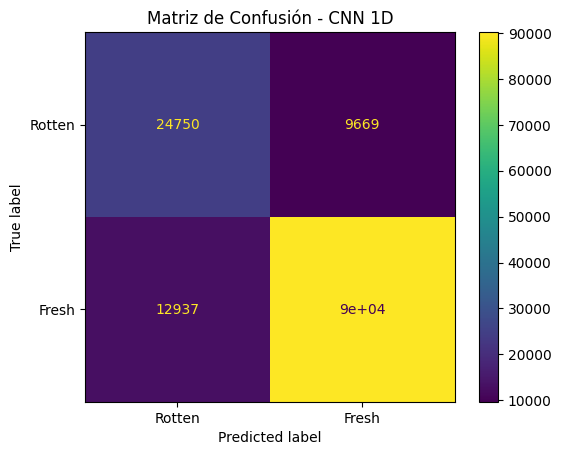

In [ ]:
# ============================================================
# 45. MATRIZ DE CONFUSIÓN CNN
# ============================================================

cnn_cm = confusion_matrix(y_true, cnn_y_pred)
cnn_disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=["Rotten", "Fresh"]
)
cnn_disp.plot()
plt.title("Matriz de Confusión - CNN 1D")
plt.show()


### 8.3 Comparación cuantitativa: BiLSTM vs CNN 1D

La comparación se realiza sobre **el mismo conjunto Test**. Además de las métricas de Keras se calcula F1 para la clase Fresh y F1 Macro, este último útil para dar el mismo peso a Fresh y Rotten pese al desbalance.


In [ ]:
# ============================================================
# 46. TABLA COMPARATIVA DE LAS DOS TÉCNICAS
# ============================================================

from sklearn.metrics import f1_score

bilstm_f1_fresh = f1_score(y_true, y_pred, pos_label=1)
bilstm_f1_macro = f1_score(y_true, y_pred, average="macro")
cnn_f1_fresh = f1_score(y_true, cnn_y_pred, pos_label=1)
cnn_f1_macro = f1_score(y_true, cnn_y_pred, average="macro")

comparacion_modelos = pd.DataFrame({
    "Modelo": ["BiLSTM", "CNN 1D"],
    "Accuracy": [results["accuracy"], cnn_results["accuracy"]],
    "Precision_Fresh": [results["precision"], cnn_results["precision"]],
    "Recall_Fresh": [results["recall"], cnn_results["recall"]],
    "F1_Fresh": [bilstm_f1_fresh, cnn_f1_fresh],
    "F1_Macro": [bilstm_f1_macro, cnn_f1_macro],
    "AUC": [results["auc"], cnn_results["auc"]]
})

comparacion_modelos.round(4)


,Modelo,Accuracy,Precision_Fresh,Recall_Fresh,F1_Fresh,F1_Macro,AUC
0,BiLSTM,0.8362,0.9124,0.8646,0.8878,0.7921,0.8994
1,CNN 1D,0.8357,0.9032,0.8746,0.8887,0.7876,0.8933


In [ ]:
# ============================================================
# 47. SELECCIÓN AUTOMÁTICA DEL MODELO FINAL
# Criterio principal: AUC; se reporta también F1 Macro.
# ============================================================

mejor_idx = comparacion_modelos["AUC"].idxmax()
mejor_nombre = comparacion_modelos.loc[mejor_idx, "Modelo"]

selected_model = model if mejor_nombre == "BiLSTM" else cnn_model

print("Modelo con mayor AUC:", mejor_nombre)
print("AUC:", round(comparacion_modelos.loc[mejor_idx, "AUC"], 4))
print("F1 Macro:", round(comparacion_modelos.loc[mejor_idx, "F1_Macro"], 4))
print()
print("Nota: si el objetivo de negocio prioriza la clase Rotten, revise además las métricas por clase antes de decidir el modelo final.")


Modelo con mayor AUC: BiLSTM
AUC: 0.8994
F1 Macro: 0.7921

Nota: si el objetivo de negocio prioriza la clase Rotten, revise además las métricas por clase antes de decidir el modelo final.


### 8.4 Análisis de Resultados

**Cómo interpretar la comparación**

1. `Accuracy` resume el porcentaje total de aciertos, pero no debe analizarse sola por el desbalance 67/33.
2. `Precision_Fresh` y `Recall_Fresh` describen el rendimiento sobre la clase positiva configurada en Keras.
3. `F1_Macro` promedia el F1 de Fresh y Rotten dando el mismo peso a ambas clases, por lo que es especialmente útil para comparar los modelos con clases desbalanceadas.
4. `AUC` mide la capacidad de separación entre clases a través de diferentes umbrales.

La celda anterior selecciona automáticamente el modelo con mayor AUC como referencia para la inferencia. Sin embargo, la decisión final puede cambiar si el objetivo de negocio prioriza específicamente detectar Rotten; en ese caso deben revisarse también Precision, Recall y F1 por clase en ambos `classification_report`.


### 8.5 Consideraciones Metodológicas

**Fortalezas**

1. Se comparan dos técnicas de Deep Learning con el mismo preprocesamiento y el mismo Test.
2. BiLSTM y CNN representan hipótesis diferentes: contexto secuencial frente a patrones locales.
3. La evaluación incorpora métricas globales y por clase, incluyendo F1 Macro y AUC.

**Limitaciones**

1. Existe desbalance entre Fresh y Rotten.
2. Por restricciones de tiempo/cómputo se usan 300 batches por época, por lo que cada época no recorre todo el Train.
3. No se realiza búsqueda sistemática de hiperparámetros; por ello la comparación corresponde a estas configuraciones concretas.

**Posibles mejoras**

1. Evaluar `class_weight` y comparar su efecto, especialmente en Rotten.
2. Entrenar con más batches/épocas y optimizar hiperparámetros de ambas arquitecturas.
3. Añadir un baseline tradicional como TF-IDF + Regresión Logística para cuantificar cuánto aporta Deep Learning.


---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

No se implementó SHAP en el notebook original. Dado que el modelo trabaja con secuencias de texto, una extensión futura podría incorporar técnicas de interpretabilidad específicas para NLP.

En la versión actual, la interpretación se complementa mediante el análisis de predicciones correctas/incorrectas y pruebas con nuevas reseñas.


In [ ]:
# ============================================================
# TABLA DE PREDICCIONES DEL MODELO SELECCIONADO
# ============================================================

selected_pred_prob = selected_model.predict(test_ds).ravel()
selected_y_pred = (selected_pred_prob >= 0.5).astype(int)

resultados = test_df[["reviewText", "reviewState"]].copy()
resultados["prob_fresh"] = selected_pred_prob
resultados["prediccion"] = np.where(
    selected_y_pred == 1,
    "Fresh",
    "Rotten"
)

print("Modelo utilizado:", mejor_nombre)
resultados.head(20)


538/538 ━━━━━━━━━━━━━━━━━━━━ 123s 228ms/step
Modelo utilizado: BiLSTM


,reviewText,reviewState,prob_fresh,prediccion
1238164,"the script is atrocious. It sounds like it's been improvised by the cast of ""Gilligan's Island"" or ""Jersey Shore"" - not written by one of our best playwrights (Jane Wagner).",rotten,0.083894,Rotten
1238165,A complex look at identity -- particularly as the son of immigrants... [Riz Ahmed] is at the top of his game.,fresh,0.967156,Fresh
1238166,"Child was a broadly entertaining public personality, and the film is broadly entertaining in turn...",fresh,0.781054,Fresh
1238167,"A bargain-basement, or really sub-bargain-basement, clone of 'Blade Runner, 'Zone 414' is visually tacky and almost infinitely dull.",rotten,0.009491,Rotten
1238168,Yakuza Princess is entertaining for diehard fans of the genre.,rotten,0.903656,Fresh
1238169,"An inherent lack of direction is part of the movie's appeal, but it ultimately feels lacking in the sort of incisive emotional power of other recent movies.",rotten,0.180719,Rotten
1238170,"Wife and husband directors Elizabeth Chai Vasarhelyi and Jimmy Chin are forensic in the detail they provide and the range of testimonies they have assembled; the result is a tense, absorbing docum...",fresh,0.994054,Fresh
1238171,"It's a delicious meal, but it often feels a touch undercooked.",fresh,0.414967,Rotten
1238172,A stunning documentary of bone-deep moral resonance and cinematic mastery that deserves to be experienced on the big screen.,fresh,0.996930,Fresh
1238173,Worth plugs its 9/11 drama about not treating people like numbers into a trite formula,rotten,0.573706,Fresh


In [ ]:
# Crear variable indicando si acertó

resultados["correcto"] = (
    resultados["reviewState"]
    ==
    resultados["prediccion"].str.lower()
)

errores = resultados[
    resultados["correcto"] == False
]

errores.head(20)

,reviewText,reviewState,prob_fresh,prediccion,correcto
1238168,Yakuza Princess is entertaining for diehard fans of the genre.,rotten,0.903656,Fresh,False
1238171,"It's a delicious meal, but it often feels a touch undercooked.",fresh,0.414967,Rotten,False
1238173,Worth plugs its 9/11 drama about not treating people like numbers into a trite formula,rotten,0.573706,Fresh,False
1238174,"The Last Matinee might be paying homage, but Contenti has his own story to tell and the modern twists make this more than just another gory rehash.",fresh,0.239329,Rotten,False
1238177,Black Widow achieves the unthinkable and dethrones Thor: The Dark World as the worst film in the Marvel Cinematic Universe.,rotten,0.837281,Fresh,False
1238181,"This good-looking sci-fi thriller has some fun set designs, but it also has a big ""been there, done that"" quality.",rotten,0.730646,Fresh,False
1238187,"Without involving bombastic devices involved, Parallel Mothers can be a melodrama, a thriller or a romantic comedy. [Full review in Spanish]",fresh,0.355434,Rotten,False
1238190,"""Worth"" is compelling because of the subject matter, not because of creativity on the part of the filmmakers.",rotten,0.983195,Fresh,False
1238200,"... emphasizes brutal katana violence over character depth, while never taking full advantage of its unique backdrop. It's more about spectacle than substance.",rotten,0.658687,Fresh,False
1238213,"Ahmed as Zed is good, but I'm not sure that he's rapping so much as reciting slam poetry, which is bad.",fresh,0.279803,Rotten,False


### 9.2 Interpretación de Negocios

Los resultados muestran que un volumen grande de opiniones no estructuradas puede convertirse automáticamente en una clasificación cuantificable de sentimiento.

**Insights Principales**

1. La clasificación automática puede reducir el esfuerzo manual necesario para revisar grandes cantidades de opiniones.
2. Las probabilidades generadas por el modelo permiten transformar texto libre en una señal que puede agregarse y monitorearse.
3. El pipeline puede adaptarse a otras fuentes empresariales como encuestas, redes sociales, tickets de soporte o reseñas de productos.

**Patrón relevante**

El desempeño no debe interpretarse solamente con Accuracy debido al desbalance entre Fresh y Rotten; métricas como Recall, Precision, F1-score y AUC permiten una lectura más completa.


#### Inferencia sobre nuevas reseñas


In [ ]:
# ============================================================
# FUNCIÓN DE PREDICCIÓN CON EL MODELO SELECCIONADO
# ============================================================

def predict_review(text):
    entrada = tf.constant([text], dtype=tf.string)
    probability = float(
        selected_model.predict(entrada, verbose=0)[0][0]
    )

    prediction = "FRESH" if probability >= 0.5 else "ROTTEN"

    print("Modelo:", mejor_nombre)
    print("Review:")
    print(text)
    print()
    print("Predicción:")
    print(prediction)
    print()
    print("Probabilidad de Fresh:", round(probability * 100, 2), "%")


In [ ]:
predict_review(
    "A brilliant movie with outstanding performances, excellent direction and a beautiful story."
)

Modelo: BiLSTM
Review:
A brilliant movie with outstanding performances, excellent direction and a beautiful story.

Predicción:
FRESH

Probabilidad de Fresh: 99.99 %


In [ ]:
predict_review(
    "The movie is boring, predictable and a complete waste of time."
)

Modelo: BiLSTM
Review:
The movie is boring, predictable and a complete waste of time.

Predicción:
ROTTEN

Probabilidad de Fresh: 0.33 %


In [ ]:
predict_review(
    "The movie has some interesting moments, but overall the story feels slow and disappointing."
)

Modelo: BiLSTM
Review:
The movie has some interesting moments, but overall the story feels slow and disappointing.

Predicción:
ROTTEN

Probabilidad de Fresh: 3.94 %


In [ ]:
def predict_api(text):
    entrada = tf.constant([text], dtype=tf.string)
    probability = float(
        selected_model.predict(entrada, verbose=0)[0][0]
    )

    prediction = "FRESH" if probability >= 0.5 else "ROTTEN"

    return {
        "model": mejor_nombre,
        "prediction": prediction,
        "fresh_probability": round(probability, 4)
    }


In [ ]:
predict_api(
    "An excellent film with brilliant acting."
)

{'model': 'BiLSTM', 'prediction': 'FRESH', 'fresh_probability': 0.9995}

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

El proyecto demuestra la viabilidad de utilizar Deep Learning y NLP para automatizar la clasificación de sentimiento en reviews cinematográficas. Después de la limpieza y preparación de datos, el pipeline transforma texto en secuencias numéricas y utiliza una arquitectura Bidirectional LSTM para aprender patrones asociados a las clases Fresh y Rotten.

El uso de un conjunto Test separado cronológicamente permite evaluar el comportamiento del modelo sobre reseñas no utilizadas para el entrenamiento. Las métricas calculadas permiten analizar su desempeño desde diferentes perspectivas.


### 10.2 Conclusiones

1. Es posible transformar grandes volúmenes de texto no estructurado en una variable de sentimiento cuantificable mediante NLP y Deep Learning.
2. Se comparan dos enfoques complementarios: la **BiLSTM**, que modela contexto secuencial, y la **CNN 1D**, que detecta patrones locales relevantes en las reseñas.
3. La arquitectura final no se decide a priori: debe seleccionarse a partir de las métricas obtenidas al ejecutar el notebook, utilizando AUC y F1 Macro como referencias y revisando el desempeño por clase.
4. La separación cronológica aproxima un escenario de generalización hacia reseñas futuras y hace la evaluación más exigente que una mezcla puramente aleatoria.
5. El desbalance Fresh/Rotten debe considerarse al interpretar resultados; por ello la comparación no se limita a Accuracy.


### 10.3 Recomendaciones de Negocio

**Corto Plazo**
1. Conectar el pipeline con fuentes reales de opiniones de clientes.
2. Integrar la salida del modelo a un dashboard de seguimiento.

**Mediano Plazo**
1. Reentrenar periódicamente el modelo con datos recientes.
2. Evolucionar de Fresh/Rotten hacia emociones más específicas.

**Largo Plazo**
1. Implementar monitoreo continuo de sentimiento en distintas fuentes.
2. Utilizar los resultados como apoyo para decisiones de contenido, marketing y experiencia del cliente.


### 10.4 Limitaciones del Estudio

1. El dataset presenta desbalance entre las clases Fresh y Rotten.
2. Ambas técnicas se entrenan con una cantidad limitada de batches por época, por lo que no se recorre todo el conjunto Train en cada época.
3. No se realiza una optimización exhaustiva de hiperparámetros; por tanto, el resultado compara estas configuraciones concretas de BiLSTM y CNN 1D.
4. No se incluye todavía un baseline tradicional ni técnicas avanzadas de interpretabilidad como SHAP.


### 10.5 Trabajo Futuro

1. Evaluar `class_weight` y otras estrategias para manejar el desbalance.
2. Optimizar hiperparámetros de BiLSTM y CNN 1D y repetir la comparación con mayor presupuesto de entrenamiento.
3. Incorporar un baseline tradicional, por ejemplo TF-IDF + Regresión Logística.
4. Evaluar arquitecturas más modernas como Transformers y técnicas de interpretabilidad para NLP.
5. Automatizar la integración con dashboards y fuentes de datos empresariales.


---
## 11. Referencias

El notebook original no especifica las referencias bibliográficas ni la URL exacta de origen del dataset.

Antes de la entrega final, completar esta sección con:

1. Fuente exacta del dataset `rotten_tomatoes_movie_reviews.csv.zip`.
2. Documentación oficial de TensorFlow/Keras utilizada para `TextVectorization`, `Embedding`, `LSTM` y métricas.
3. Cualquier material académico o bibliográfico empleado para justificar la arquitectura y metodología.


---
## Anexos

### A. Guardado del Modelo


In [ ]:
# ============================================================
# GUARDAR MODELOS Y MODELO SELECCIONADO
# ============================================================

model.save("/content/movie_sentiment_bilstm.keras")
cnn_model.save("/content/movie_sentiment_cnn.keras")
selected_model.save("/content/movie_sentiment_best.keras")

print("BiLSTM guardada en: /content/movie_sentiment_bilstm.keras")
print("CNN guardada en: /content/movie_sentiment_cnn.keras")
print("Modelo seleccionado (", mejor_nombre, ") guardado en: /content/movie_sentiment_best.keras")


### B. Cargar Modelo Guardado (para Inferencia)

Ejemplo para reutilizar el modelo guardado:


In [ ]:
# Cargar el modelo previamente guardado
# loaded_model = keras.models.load_model("/content/movie_sentiment_model.keras")
# loaded_model.summary()


---
## Checklist de Entrega

- [x] Información del proyecto estructurada
- [x] Resumen ejecutivo
- [x] Problema de negocio definido
- [x] Objetivos establecidos
- [x] EDA con visualizaciones
- [x] Preprocesamiento documentado
- [x] Arquitectura justificada
- [x] Entrenamiento y curvas de aprendizaje
- [x] Métricas de evaluación
- [ ] Comparación cuantitativa con modelo baseline
- [x] Interpretación de resultados
- [x] Conclusiones y recomendaciones
- [ ] Referencias bibliográficas completas
- [x] Guardado e inferencia del modelo
